In [28]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

try:
    import rasterio
    HAS_RASTERIO = True
except ImportError:
    HAS_RASTERIO = False
    print("rasterio is not installed. Real GeoTIFF loading will not work, but the synthetic demo will still run.")

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = False

# Sentinel-1 C-band wavelength, approximately.
# One full phase cycle corresponds to lambda / 2 of round-trip LOS displacement.
S1_WAVELENGTH_M = 0.0555
FRINGE_TO_LOS_M = S1_WAVELENGTH_M / 2

print(f"Sentinel-1 wavelength: {S1_WAVELENGTH_M:.4f} m")
print(f"One full fringe/cycle corresponds to about {FRINGE_TO_LOS_M*100:.2f} cm of LOS displacement.")

Sentinel-1 wavelength: 0.0555 m
One full fringe/cycle corresponds to about 2.77 cm of LOS displacement.


In [29]:
# Change this path to wherever your SNAP GeoTIFF exports are stored.
DATA_DIR = Path("data")

VOLCANO_WRAPPED_PHASE = DATA_DIR / "kilauea_20180514_20180508_wrapped_phase.tif"
VOLCANO_COHERENCE = DATA_DIR / "kilauea_20180514_20180508_coherence.tif"
VOLCANO_UNWRAPPED_LOS = DATA_DIR / "kilauea_20180514_20180508_unwrapped_los_m.tif"
VOLCANO_DEM = DATA_DIR / "kilauea_dem.tif"

USE_SYNTHETIC_IF_MISSING = True

In [30]:
def read_single_band_geotiff(path):
    '''
    Read the first band of a GeoTIFF.

    Returns
    -------
    array : 2-D numpy array
    profile : rasterio profile dictionary
    '''
    if not HAS_RASTERIO:
        raise ImportError("rasterio is required to read GeoTIFFs.")

    path = Path(path)
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        profile = src.profile.copy()
        nodata = src.nodata
        if nodata is not None:
            arr[arr == nodata] = np.nan
    return arr, profile


def wrap_phase(phase_rad):
    '''
    Wrap any phase array into the interval [-pi, pi].
    '''
    return (phase_rad + np.pi) % (2 * np.pi) - np.pi


def robust_limits(arr, pmin=2, pmax=98):
    '''
    Percentile color limits, ignoring NaNs.
    '''
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        return None, None
    return np.percentile(finite, [pmin, pmax])


def plot_raster(arr, title="", cmap="viridis", vmin=None, vmax=None, cbar_label=""):
    '''
    Simple raster plot helper.
    '''
    fig, ax = plt.subplots()
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Column")
    ax.set_ylabel("Row")
    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    if cbar_label:
        cbar.set_label(cbar_label)
    plt.show()

def make_projected_grid_from_profile(profile):
    """
    Build x/y coordinate grids from a projected GeoTIFF profile.

    Assumes the raster CRS is projected in meters, e.g. EPSG:32605.
    """
    transform = profile["transform"]
    nrows = profile["height"]
    ncols = profile["width"]

    cols = np.arange(ncols)
    rows = np.arange(nrows)

    cc, rr = np.meshgrid(cols, rows)

    # Pixel center coordinates
    xx = transform.c + (cc + 0.5) * transform.a + (rr + 0.5) * transform.b
    yy = transform.f + (cc + 0.5) * transform.d + (rr + 0.5) * transform.e

    return xx, yy

Loaded real SNAP volcano wrapped phase and coherence.


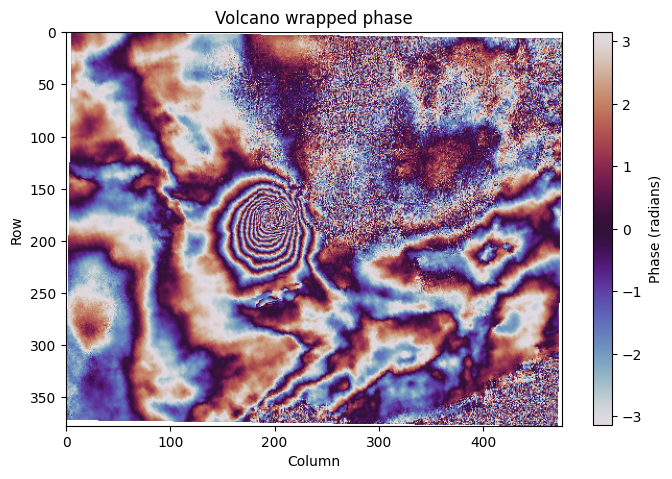

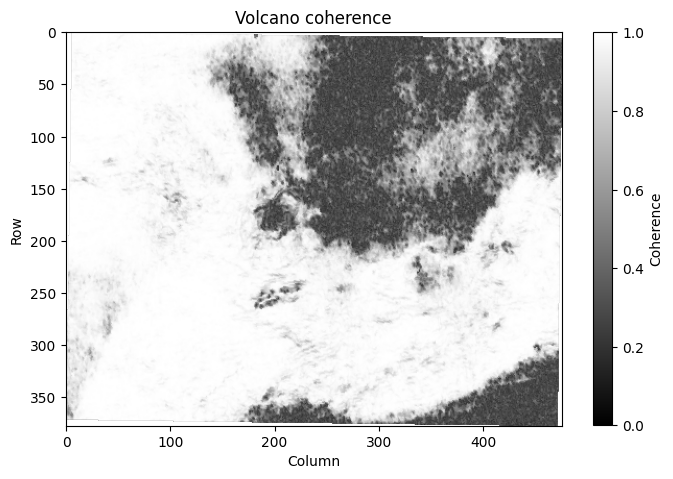

In [33]:
def make_synthetic_volcano_ifg(n=350, pixel_size_m=60, source_depth_m=2500,
                               amplitude_m=0.16, noise_rad=0.25, seed=4):
    '''
    Create a synthetic wrapped volcano-like interferogram.

    This is only for testing the notebook before SNAP products are available.
    It is not a substitute for the real Kilauea interferogram.
    '''
    rng = np.random.default_rng(seed)

    x = (np.arange(n) - n / 2) * pixel_size_m
    y = (np.arange(n) - n / 2) * pixel_size_m
    xx, yy = np.meshgrid(x, y)

    # Slightly off-center synthetic source.
    x0 = -1800
    y0 = 900
    r2 = (xx - x0)**2 + (yy - y0)**2
    d = source_depth_m

    # Compact uplift-like LOS displacement pattern.
    los_m = amplitude_m * d**3 / (r2 + d**2)**1.5

    # Add a gentle atmospheric ramp and noise.
    ramp = 0.015 * (xx / np.nanmax(np.abs(xx))) + 0.01 * (yy / np.nanmax(np.abs(yy)))
    los_m = los_m + ramp

    phase = (4 * np.pi / S1_WAVELENGTH_M) * los_m
    wrapped = wrap_phase(phase + rng.normal(0, noise_rad, phase.shape))

    # Synthetic coherence: high near coherent summit/lava fields, lower in patches.
    coherence = 0.85 - 0.25 * rng.random((n, n))
    low_patch = ((xx + 5500)**2 / (3500**2) + (yy - 4500)**2 / (2500**2)) < 1
    coherence[low_patch] *= 0.45
    coherence = np.clip(coherence, 0, 1)

    return wrapped, coherence, los_m, xx, yy


real_volcano_files_available = (
    VOLCANO_WRAPPED_PHASE.exists()
    and VOLCANO_COHERENCE.exists()
    and HAS_RASTERIO
)

if real_volcano_files_available:
    wrapped_phase, wrapped_profile = read_single_band_geotiff(VOLCANO_WRAPPED_PHASE)
    coherence, coherence_profile = read_single_band_geotiff(VOLCANO_COHERENCE)
    synthetic_los_for_testing = None
    x_m = y_m = None
    print("Loaded real SNAP volcano wrapped phase and coherence.")
else:
    if not USE_SYNTHETIC_IF_MISSING:
        raise FileNotFoundError("SNAP volcano products are missing and USE_SYNTHETIC_IF_MISSING is False.")
    wrapped_phase, coherence, synthetic_los_for_testing, x_m, y_m = make_synthetic_volcano_ifg()
    wrapped_profile = coherence_profile = None
    print("Real SNAP files not found. Using synthetic volcano interferogram for notebook testing.")

plot_raster(wrapped_phase, title="Volcano wrapped phase", cmap="twilight", vmin=-np.pi, vmax=np.pi, cbar_label="Phase (radians)")
plot_raster(coherence, title="Volcano coherence", cmap="gray", vmin=0, vmax=1, cbar_label="Coherence")

QUESTION: One complete color cycle in a Sentinel-1 wrapped interferogram corresponds to approximately how much line-of-sight displacement? Explain why the factor is λ/2, not λ.

ANSWER: The radar wave travels from satellite -> ground -> satellite, a ground displacement changes the total path length by 2, doubling the phase sensitivity.

QUESTION: What threshold did you choose and why? Are you masking real deformation, or mostly bad phase due to decorrelation? Why is there no universally correct coherence threshold?

ANSWER: I chose a coherence threshold of 0.4 because pixels below this value appeared dominated by decorrelation noise rather than coherent deformation. The threshold masks mostly unreliable phase while preserving most deformation fringes. There is no universally correct threshold because the optimal value depends on land cover, acquisition geometry, temporal baseline, and analysis goals.

Coherence threshold: 0.4
Fraction of pixels kept: 77.62%


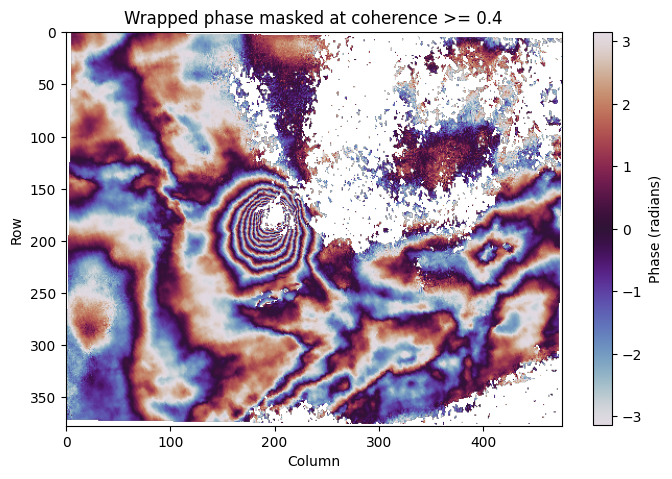

In [34]:
COHERENCE_THRESHOLD = 0.4

phase_masked = np.where(coherence >= COHERENCE_THRESHOLD, wrapped_phase, np.nan)
fraction_kept = np.isfinite(phase_masked).sum() / phase_masked.size

print(f"Coherence threshold: {COHERENCE_THRESHOLD}")
print(f"Fraction of pixels kept: {fraction_kept:.2%}")

plot_raster(
    phase_masked,
    title=f"Wrapped phase masked at coherence >= {COHERENCE_THRESHOLD}",
    cmap="twilight",
    vmin=-np.pi,
    vmax=np.pi,
    cbar_label="Phase (radians)"
)

QUESTION: Count the approximate number of fringes from the deformation center to the background, and convert that fringe count to approximate LOS displacement. Is your estimate a minimum, maximum, or rough characteristic value?

ANSWER: I estimate approximately 6 fringes between the deformation center and the surrounding background. The estimated LOS displacement is approximately 16.7 cm. This estimate should be interpreted as a rough characteristic value because fringe counting from a wrapped interferogram is approximate and depends on where the deformation gradually merges into background noise and on areas removed by coherence masking.

QUESTION: Does positive LOS displacement mean uplift or subsidence, and why?

ANSWER: positive LOS displacement -> ground moved toward the satellite. For Sentinel-1 movement toward the satellite is often associated with uplift, but horizontal motion toward the sensor can produce the same positive LOS signal. LOS displacement measures motion projected onto the satellite viewing direction.

In [35]:
# Fill this in manually after inspecting the wrapped interferogram.
estimated_fringe_count = 6

estimated_los_change_m = estimated_fringe_count * FRINGE_TO_LOS_M

print(f"Estimated fringe count: {estimated_fringe_count:.1f}")
print(f"Approximate LOS change: {estimated_los_change_m:.3f} m")
print(f"Approximate LOS change: {estimated_los_change_m*100:.1f} cm")

Estimated fringe count: 6.0
Approximate LOS change: 0.167 m
Approximate LOS change: 16.7 cm


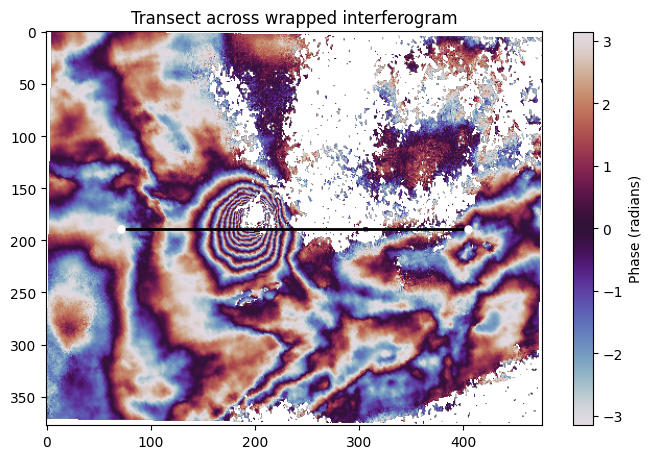

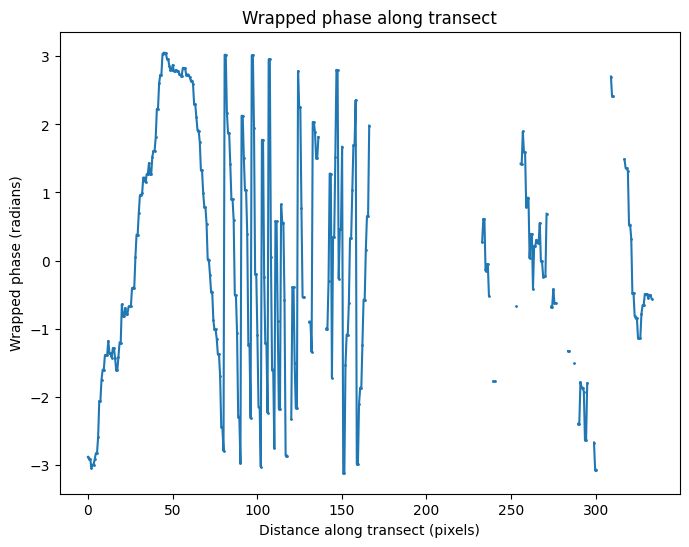

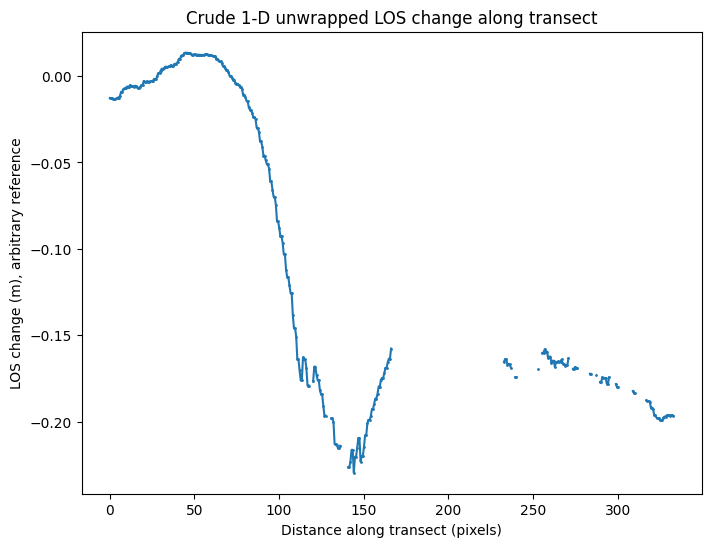

In [36]:
def sample_transect(arr, row0, col0, row1, col1, npts=500):
    '''
    Sample a raster along a straight line in row/column coordinates using nearest-neighbor sampling.
    '''
    rows = np.linspace(row0, row1, npts)
    cols = np.linspace(col0, col1, npts)

    rr = np.clip(np.round(rows).astype(int), 0, arr.shape[0] - 1)
    cc = np.clip(np.round(cols).astype(int), 0, arr.shape[1] - 1)

    profile = arr[rr, cc]
    distance_px = np.sqrt((rows - rows[0])**2 + (cols - cols[0])**2)

    return distance_px, profile, rows, cols


# Edit these transect endpoints after looking at the image.
nrows, ncols = wrapped_phase.shape
row0, col0 = int(0.50 * nrows), int(0.15 * ncols)
row1, col1 = int(0.50 * nrows), int(0.85 * ncols)

dist_px, phase_profile, rows, cols = sample_transect(phase_masked, row0, col0, row1, col1)

# Plot transect location
fig, ax = plt.subplots()
im = ax.imshow(phase_masked, cmap="twilight", vmin=-np.pi, vmax=np.pi)
ax.plot([col0, col1], [row0, row1], "k-", linewidth=2)
ax.plot([col0, col1], [row0, row1], "wo", markersize=5)
ax.set_title("Transect across wrapped interferogram")
plt.colorbar(im, ax=ax, shrink=0.85, label="Phase (radians)")
plt.show()

# Plot wrapped phase profile
fig, ax = plt.subplots()
ax.plot(dist_px, phase_profile, ".-", markersize=2)
ax.set_title("Wrapped phase along transect")
ax.set_xlabel("Distance along transect (pixels)")
ax.set_ylabel("Wrapped phase (radians)")
plt.show()

# A crude 1-D unwrap only along this transect.
# This is not a replacement for 2-D phase unwrapping.
valid = np.isfinite(phase_profile)
unwrapped_profile = np.full_like(phase_profile, np.nan, dtype=float)
if valid.sum() > 5:
    unwrapped_profile[valid] = np.unwrap(phase_profile[valid])
    los_profile_m = unwrapped_profile * S1_WAVELENGTH_M / (4 * np.pi)

    fig, ax = plt.subplots()
    ax.plot(dist_px, los_profile_m, ".-", markersize=2)
    ax.set_title("Crude 1-D unwrapped LOS change along transect")
    ax.set_xlabel("Distance along transect (pixels)")
    ax.set_ylabel("LOS change (m), arbitrary reference")
    plt.show()
else:
    print("Not enough valid points along transect for 1-D unwrap.")


QUESTION: What displacement components does a volcano pressure source create? Why can ascending and descending interferograms have different signs or shapes? How would GNSS complement InSAR here?

ANSWER: A volcano pressure source produces both vertical and horizontal displacement components. InSAR does not measure full 3-D displacement directly. It measures only LOS displacement, which is the projection of total ground motion onto the satellite viewing direction. The sign of LOS displacement can change if horizontal motion projects toward the satellite in one geometry and away in another, and the shape and amplitude of fringes can differ because each orbit is sensitive to different east–west and vertical motion combinations. Combining GNSS with ascending and descending InSAR allows reconstruction of a more complete 3-D deformation field, separates vertical from horizontal motion, and helps constrain the depth, geometry, and pressure change of the volcanic source.

QUESTION: How is the unwrapped displacement different from the wrapped phase image? What is the approximate maximum LOS displacement?

ANSWER: The unwrapped displacement map represents continuous LOS displacement in meters, rather than phase values wrapped into the interval [-π, π]. Displacement larger than one phase cycle appears repeatedly as color fringes, making the total displacement ambiguous. Unwrapping removes these 2π discontinuities and reconstructs a continuous deformation field that can be interpreted quantitatively. The approximate maximum LOS displacement is 12.5 cm.

QUESTION: What might be real source complexity, and what might be atmospheric or processing artifact?

ANSWER: Real source complexity may include: multiple magma reservoirs, asymmetric pressure sources, dike intrusion, fault slip, spatially variable deformation.
Atmospheric or processing artifacts may include: tropospheric water vapor effects, orbital ramps, phase unwrapping errors, decorrelation, DEM/topographic residual errors, noise in low-coherence regions.
Real volcanic deformation tends to produce smooth, geologically meaningful spatial patterns, whereas artifacts often appear as broad gradients, isolated patches, streaks, or noisy textures.

QUESTION: Look at the residual map: observed minus modeled LOS displacement. Where does the model fail? Are the failures random, spatially organized, or concentrated in low-coherence areas?

ANSWER: The model failures occur in two main patterns:
Spatially organized failures: The dominant residual structure is coherent, with broad gradients and a circular feature, indicating systematic misfit.
Concentrated in low-coherence areas: Additional residuals appear as noisy, high-frequency patches in the upper-right and bottom-right regions, consistent with decorrelation and phase unwrapping errors where the data quality is low.

Loaded real/provided unwrapped LOS displacement.


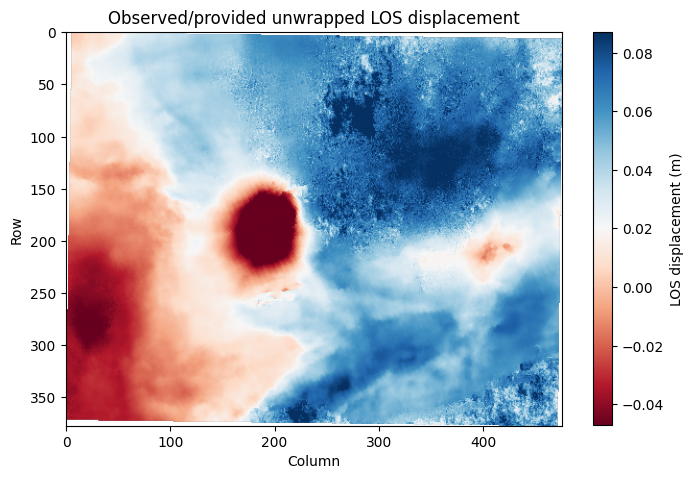

Approximate LOS min: -0.246 m
Approximate LOS max: 0.125 m
Approximate LOS range: 0.372 m


In [37]:
def load_unwrapped_or_synthetic():
    if VOLCANO_UNWRAPPED_LOS.exists() and HAS_RASTERIO:
        arr, profile = read_single_band_geotiff(VOLCANO_UNWRAPPED_LOS)
        print("Loaded real/provided unwrapped LOS displacement.")
        return arr, profile
    else:
        print("Provided unwrapped LOS file not found. Using synthetic LOS displacement for testing.")
        if synthetic_los_for_testing is not None:
            # Set an arbitrary reference by subtracting median border value.
            los = synthetic_los_for_testing.copy()
            border = np.concatenate([los[0, :], los[-1, :], los[:, 0], los[:, -1]])
            los = los - np.nanmedian(border)
            return los, None
        else:
            raise FileNotFoundError("No unwrapped LOS file and no synthetic LOS available.")


volcano_los_obs_m, volcano_los_profile = load_unwrapped_or_synthetic()

vmin, vmax = robust_limits(volcano_los_obs_m, 2, 98)
plot_raster(
    volcano_los_obs_m,
    title="Observed/provided unwrapped LOS displacement",
    cmap="RdBu",
    vmin=vmin,
    vmax=vmax,
    cbar_label="LOS displacement (m)"
)

print(f"Approximate LOS min: {np.nanmin(volcano_los_obs_m):.3f} m")
print(f"Approximate LOS max: {np.nanmax(volcano_los_obs_m):.3f} m")
print(f"Approximate LOS range: {np.nanmax(volcano_los_obs_m) - np.nanmin(volcano_los_obs_m):.3f} m")

QUESTION: Why do source models need coordinates in meters rather than pixels?

ANSWER: Source models need coordinates in meters rather than pixels because the physics of deformation is defined in real-world space, not image indexing space. Pixels are just array indices: they tell you where something is in the image, but they do not encode actual distance unless you separately know the pixel spacing.

In [38]:
def make_local_grid_from_shape(shape, pixel_size_m=60):
    '''
    Create a simple local x/y grid centered on the image.

    x is positive east-like.
    y is positive north-like.
    '''
    nrows, ncols = shape
    x = (np.arange(ncols) - ncols / 2) * pixel_size_m
    y = (np.arange(nrows) - nrows / 2) * pixel_size_m
    xx, yy = np.meshgrid(x, y)
    return xx, yy


# If using real GeoTIFFs exported in degrees, choose a representative pixel size manually.
# For Kilauea Sentinel-1 products, this depends on your SNAP terrain-correction/export settings.
PIXEL_SIZE_M_APPROX = 60
if real_volcano_files_available:
    xx_m, yy_m = make_projected_grid_from_profile(volcano_los_profile)

    # Center coordinates around zero for easier source-model parameters
    xx_m = xx_m - np.nanmean(xx_m)
    yy_m = yy_m - np.nanmean(yy_m)
else:
    xx_m, yy_m = make_local_grid_from_shape(volcano_los_obs_m.shape, pixel_size_m=PIXEL_SIZE_M_APPROX)

print(f"x range: {np.nanmin(xx_m)/1000:.1f} to {np.nanmax(xx_m)/1000:.1f} km")
print(f"y range: {np.nanmin(yy_m)/1000:.1f} to {np.nanmax(yy_m)/1000:.1f} km")

x range: -21.2 to 21.2 km
y range: -16.8 to 16.8 km


QUESTION: What happens when you make the source deeper? What happens when you make the source stronger? What happens when you move the source laterally?

ANSWER: Making the source deeper: The surface deformation becomes broader and smoother, with a much larger wavelength pattern. The peak displacement decreases, so the signal looks more diffuse and less localized. In other words, depth spreads the deformation out and weakens the maximum amplitude at the surface.
Making the source stronger: The overall amplitude of displacement increases everywhere, but the spatial shape of the pattern stays the same. You get taller uplift/subsidence signals without changing the footprint or wavelength of the deformation.
Moving the source laterally: The entire deformation pattern shifts across the map. The center of uplift/subsidence moves to the new source location, but the shape and decay structure remain the same—just repositioned in space.

In [39]:
def simple_pressure_source_displacement(xx, yy, x0_m=0, y0_m=0, depth_m=2500, strength=1.0, poisson=0.25):
    '''
    Crude Mogi-style pressure source displacement.

    Parameters
    ----------
    xx, yy : 2-D arrays
        Local coordinates in meters.
    x0_m, y0_m : float
        Source location in meters.
    depth_m : float
        Positive source depth below the surface in meters.
    strength : float
        Source strength / volume-change-like scale factor.
        This is pedagogical, not a carefully calibrated physical parameter.
    poisson : float
        Poisson ratio.

    Returns
    -------
    ue, un, uu : 2-D arrays
        East-like, north-like, and up displacement components in meters.
    '''
    dx = xx - x0_m
    dy = yy - y0_m
    dz = depth_m

    r2 = dx**2 + dy**2 + dz**2
    r3 = r2**1.5

    scale = (1 - poisson) * strength / np.pi

    ue = scale * dx / r3
    un = scale * dy / r3
    uu = scale * dz / r3

    return ue, un, uu


def los_unit_vector(incidence_deg=39, look_azimuth_deg=270):
    '''
    Approximate unit vector from ground toward satellite.

    incidence_deg:
        Incidence angle from vertical.
    look_azimuth_deg:
        Direction from ground toward satellite, clockwise from north.
        For a simple descending right-looking approximation, west-looking is about 270 degrees.
        For a simple ascending right-looking approximation, east-looking is about 90 degrees.

    Returns
    -------
    los_e, los_n, los_u
    '''
    inc = np.deg2rad(incidence_deg)
    az = np.deg2rad(look_azimuth_deg)

    los_e = np.sin(inc) * np.sin(az)
    los_n = np.sin(inc) * np.cos(az)
    los_u = np.cos(inc)

    return los_e, los_n, los_u


def project_to_los(ue, un, uu, incidence_deg=39, look_azimuth_deg=270, sign=1):
    '''
    Project 3-D displacement into approximate radar LOS.

    Positive values are motion toward the satellite under this convention.
    Use sign=-1 if your unwrapped product uses the opposite convention.
    '''
    los_e, los_n, los_u = los_unit_vector(incidence_deg, look_azimuth_deg)
    return sign * (ue * los_e + un * los_n + uu * los_u)

QUESTION: Which parameter mostly controls the width of the deformation pattern? Which parameter mostly controls the amplitude?

ANSWER: Width of the deformation pattern: source_depth_m controls the spatial width. A deeper source produces a broader, more spread-out deformation field, while a shallower source creates a more compact, sharply localized signal.
Amplitude of the deformation: source_strength primarily controls the amplitude. Increasing it scales the magnitude of uplift/subsidence everywhere, making the signal stronger without significantly changing its spatial shape.

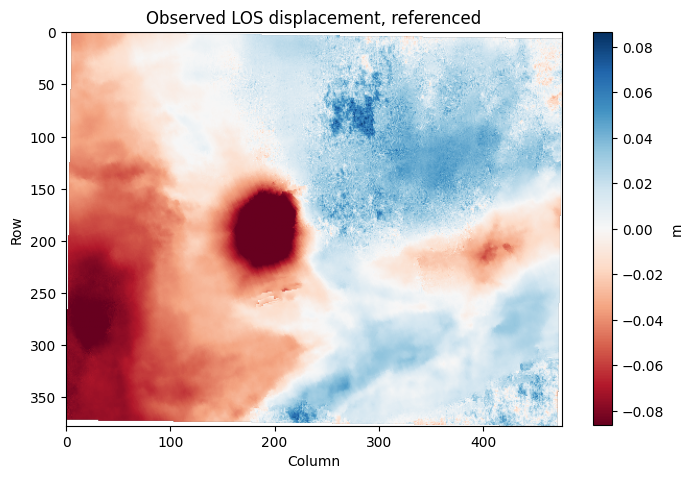

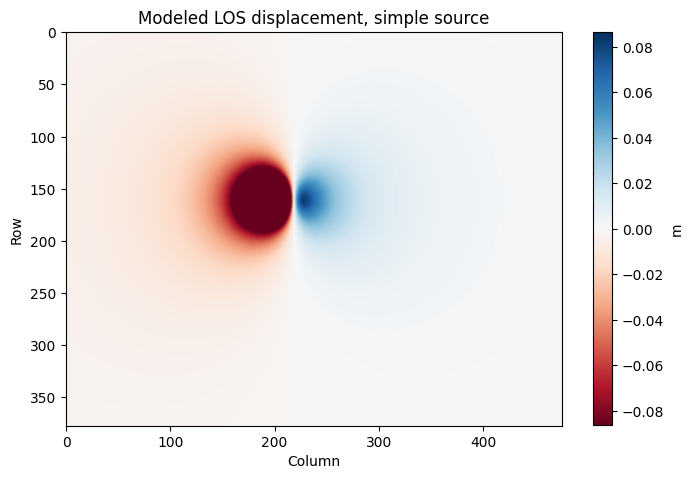

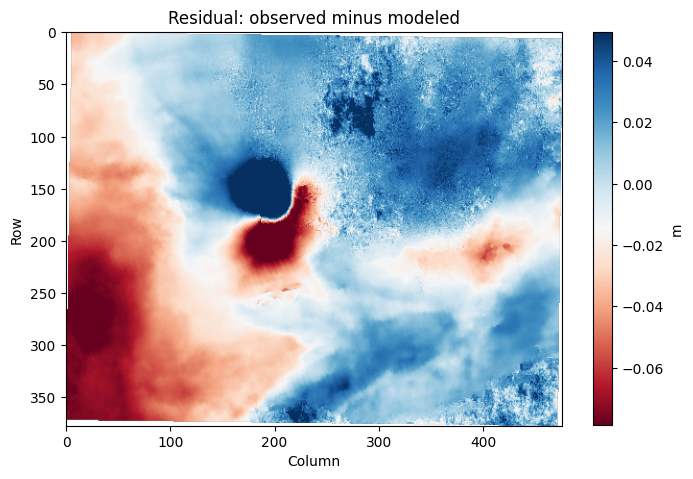

RMSE: 0.0567 m


In [40]:
# Try changing these parameters.
source_x_m = -3000
source_y_m = 2500
source_depth_m = 1000

# This strength value is not intuitive in isolation.
# Adjust it until the modeled displacement amplitude is comparable to the observation.
source_strength = 8e6

incidence_deg = 39
look_azimuth_deg = 270
los_sign = -1

ue, un, uu = simple_pressure_source_displacement(
    xx_m, yy_m,
    x0_m=source_x_m,
    y0_m=source_y_m,
    depth_m=source_depth_m,
    strength=source_strength
)

volcano_los_model_m = project_to_los(
    ue, un, uu,
    incidence_deg=incidence_deg,
    look_azimuth_deg=look_azimuth_deg,
    sign=los_sign
)

# Remove arbitrary reference offset from model and observation before comparing.
obs_ref = volcano_los_obs_m - np.nanmedian(volcano_los_obs_m)
model_ref = volcano_los_model_m - np.nanmedian(volcano_los_model_m)
residual = obs_ref - model_ref

lim = np.nanpercentile(np.abs(np.concatenate([
    obs_ref[np.isfinite(obs_ref)].ravel(),
    model_ref[np.isfinite(model_ref)].ravel()
])), 98)

plot_raster(obs_ref, title="Observed LOS displacement, referenced", cmap="RdBu", vmin=-lim, vmax=lim, cbar_label="m")
plot_raster(model_ref, title="Modeled LOS displacement, simple source", cmap="RdBu", vmin=-lim, vmax=lim, cbar_label="m")

rvmin, rvmax = robust_limits(residual, 2, 98)
plot_raster(residual, title="Residual: observed minus modeled", cmap="RdBu", vmin=rvmin, vmax=rvmax, cbar_label="m")

rmse = np.sqrt(np.nanmean(residual**2))
print(f"RMSE: {rmse:.4f} m")

QUESTION: Which changes produce obvious visual differences? Which parameters trade off with each other?

ANSWER: Changing source depth strongly alters the shape and width of the deformation pattern. This is very visually obvious because the entire signal becomes either tightly concentrated or broadly smeared out.
Changing source strength mainly affects the amplitude. This is also clearly visible because the same pattern becomes brighter or weaker, but its geometry stays similar.
Changing lateral position shifts the entire deformation pattern across the map, which is immediately noticeable because peaks and troughs move location.

QUESTION: Why is a residual map useful?

ANSWER: It shows where and how the model fails spatially, rather than just giving a single error value like RMSE.

QUESTION: Does the lowest RMSE necessarily mean the most geologically correct model? Why or why not? What assumptions did we make before running the inversion?

ANSWER: the lowest RMSE does not necessarily mean the most geologically correct model. RMSE only measures how well the model matches the observed data within the assumptions of the chosen model, not whether those assumptions are physically or geologically valid. The inversion is non-unique, the model is simplified physics, the inversion may explain real signals using the wrong mechanism, but still achieve low residual error, noise and unmodeled effects can bias the fit.

In [44]:
!pip install scipy

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/36.6 MB ? eta -:--:--
    --------------------------------------- 0.5/36.6 MB 670.4 kB/s eta 0:00:54
    --------------------------------------- 0.5/36.6 MB 670.4 kB/s eta 0:00:54
    --------------------------------------- 0.8/36.6 MB 699.0 kB/s eta 0:00:52
    --------------------------------------- 0.8/36.6 MB 699.0 kB/s eta 0:00:52
   - -------------------------------------- 1.3/36.6 MB 799.2 kB/s eta 0:00:45
   - -------------------------------------- 1.6/36.6 MB 902.1 kB/s eta 0:00:39
   -- ------------------------------------- 2.1/36.6 MB 1.1 MB/s eta 0:00:33
   -- ------------------------------------- 2.6/36.6 MB 1.2 MB/s eta 0:00:28
   ---- ----------------------------------- 3.7/36.6 MB 1.6 MB/s eta 0:00:21
   ----- ------

In [45]:
from scipy.optimize import least_squares

# Downsample so the inversion runs quickly.
step = 5

obs = volcano_los_obs_m[::step, ::step]
xg = xx_m[::step, ::step]
yg = yy_m[::step, ::step]
coh = coherence[::step, ::step]

# Use only coherent, finite pixels.
mask = (
    np.isfinite(obs)
    & np.isfinite(xg)
    & np.isfinite(yg)
    & (coh >= COHERENCE_THRESHOLD)
)

obs_vec = obs[mask]

# Remove arbitrary displacement reference.
obs_vec = obs_vec - np.nanmedian(obs_vec)



def predict_los_from_params(params):
    """
    params = [x0_m, y0_m, depth_m, strength_scaled]
    strength = strength_scaled * 1e6
    """
    x0_m, y0_m, depth_m, strength_scaled = params
    strength = strength_scaled * 1e6

    ue, un, uu = simple_pressure_source_displacement(
        xg, yg,
        x0_m=x0_m,
        y0_m=y0_m,
        depth_m=depth_m,
        strength=strength
    )

    model = project_to_los(
        ue, un, uu,
        incidence_deg=incidence_deg,
        look_azimuth_deg=look_azimuth_deg,
        sign=los_sign
    )

    model_vec = model[mask]
    model_vec = model_vec - np.nanmedian(model_vec)

    return model_vec


def residual_function(params):
    model_vec = predict_los_from_params(params)
    return obs_vec - model_vec

p0 = [-700, 1000, 2500, 4.0]   # strength = 3.0e6



lower_bounds = [-10000, -10000, 500, 0.1]
upper_bounds = [10000, 10000, 10000, 100]

result = least_squares(
    residual_function,
    p0,
    bounds=(lower_bounds, upper_bounds),
    max_nfev=500,
    xtol=1e-12,
    ftol=1e-12,
    gtol=1e-12,
    x_scale=[3000, 3000, 3000, 10],
    verbose=2
)

best_x, best_y, best_depth, best_strength_scaled = result.x
best_strength = best_strength_scaled * 1e6

print("Best-fitting parameters:")
print(f"x0:       {best_x:.0f} m")
print(f"y0:       {best_y:.0f} m")
print(f"depth:    {best_depth:.0f} m")
print(f"strength: {best_strength:.3e}")

rmse = np.sqrt(np.mean(result.fun**2))
print(f"RMSE:     {rmse:.4f} m")

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.4276e+00                                    5.49e+00    
       1              2         2.8008e+00      6.27e-01       2.90e+03       7.72e+00    
       2              3         2.5185e+00      2.82e-01       1.51e+03       1.29e+00    
       3              4         2.4842e+00      3.43e-02       7.49e+02       3.59e-01    
       4              5         2.4749e+00      9.27e-03       3.52e+02       2.04e-01    
       5              6         2.4706e+00      4.30e-03       2.05e+02       5.87e-02    
       6              7         2.4681e+00      2.51e-03       1.53e+02       1.19e-01    
       7              8         2.4668e+00      1.35e-03       1.18e+02       6.31e-02    
       8              9         2.4661e+00      6.34e-04       1.32e+02       1.79e-01    
       9             10         2.4659e+00      2.30e-04       5.58e+01       8.25e-03    

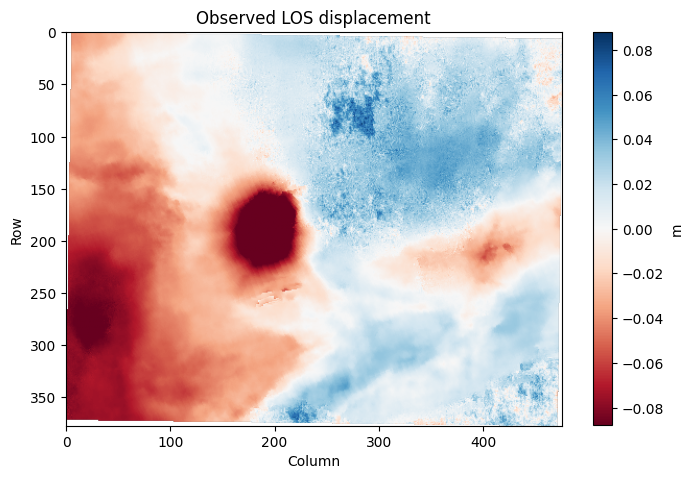

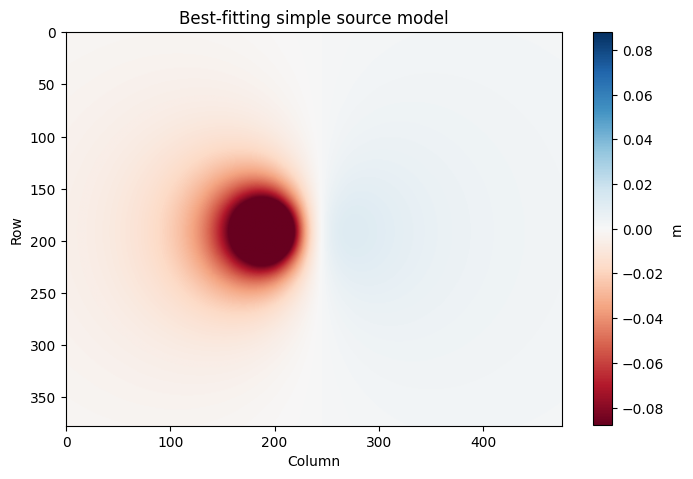

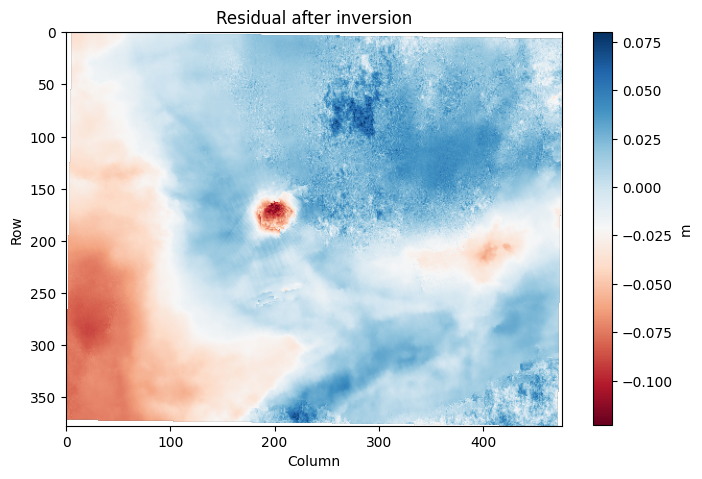

Best inversion RMSE: 0.0298 m


In [46]:
def run_volcano_model_test(
    source_x_m=-1500,
    source_y_m=1000,
    source_depth_m=2500,
    source_strength=1.2e9,
    incidence_deg=39,
    look_azimuth_deg=270,
    los_sign=1,
    obs=None,
    mask=None
):
    """
    Run the simple volcano pressure-source model and compare it to observed LOS displacement.

    Returns
    -------
    model_ref : 2-D array
        Referenced modeled LOS displacement.
    residual : 2-D array
        Observed minus modeled LOS displacement.
    rmse : float
        Root-mean-square residual in meters.
    """

    if obs is None:
        obs = volcano_los_obs_m

    ue, un, uu = simple_pressure_source_displacement(
        xx_m, yy_m,
        x0_m=source_x_m,
        y0_m=source_y_m,
        depth_m=source_depth_m,
        strength=source_strength
    )

    model = project_to_los(
        ue, un, uu,
        incidence_deg=incidence_deg,
        look_azimuth_deg=look_azimuth_deg,
        sign=los_sign
    )

    # Apply optional mask, for example coherence mask.
    if mask is not None:
        obs_use = np.where(mask, obs, np.nan)
        model_use = np.where(mask, model, np.nan)
    else:
        obs_use = obs.copy()
        model_use = model.copy()

    # Remove arbitrary reference level from both fields.
    obs_ref = obs_use - np.nanmedian(obs_use)
    model_ref = model_use - np.nanmedian(model_use)

    residual = obs_ref - model_ref

    rmse = np.sqrt(np.nanmean(residual**2))

    return model_ref, residual, rmse


best_model, best_residual, best_rmse = run_volcano_model_test(
    source_x_m = best_x,
    source_y_m = best_y,
    source_depth_m = best_depth,
    source_strength = best_strength,
    incidence_deg = incidence_deg,
    look_azimuth_deg = look_azimuth_deg,
    los_sign = los_sign
)

lim = np.nanpercentile(np.abs(np.concatenate([
    obs_ref[np.isfinite(obs_ref)].ravel(),
    best_model[np.isfinite(best_model)].ravel()
])), 98)

plot_raster(obs_ref, title="Observed LOS displacement", cmap="RdBu", vmin=-lim, vmax=lim, cbar_label="m")
plot_raster(best_model, title="Best-fitting simple source model", cmap="RdBu", vmin=-lim, vmax=lim, cbar_label="m")
plot_raster(best_residual, title="Residual after inversion", cmap="RdBu", cbar_label="m")

print(f"Best inversion RMSE: {best_rmse:.4f} m")